In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PageRank on the arXiv High Energy Physics Collaboration Network
A Distributed Link Analysis Study using Apache Spark

Author: Selam Mahmud Ali
Course: Algorithms for Massive Data - MSc in Data Science for Economics
Supervisor: Prof. Dario Malchiodi
A.Y.: 2025/2026

Google Colab version — run cells in order from top to bottom.
"""

# ══════════════════════════════════════════════════════════════════════════════
# 1 — ENVIRONMENT SETUP
# ══════════════════════════════════════════════════════════════════════════════
import os
import subprocess

# Install required packages
subprocess.run(["pip", "install", "pyspark==4.1.1", "findspark", "kaggle", "--quiet"])

# Set Java 17 path (already installed on Colab)
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

# Set Kaggle credentials from Colab Secrets
# Before running: click the key icon in the left sidebar and add:
# KAGGLE_USERNAME = your kaggle username
# KAGGLE_KEY      = your kaggle API key
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

# Write kaggle.json config file
os.makedirs("/root/.config/kaggle", exist_ok=True)
with open("/root/.config/kaggle/kaggle.json", "w") as f:
    f.write(f'{{"username":"{os.environ["KAGGLE_USERNAME"]}","key":"{os.environ["KAGGLE_KEY"]}"}}'
)
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)

print("Environment setup complete.")


Environment setup complete.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
import os
import re
import json
import sys
import findspark
import kaggle
import pyspark
from itertools import combinations
from pyspark.sql import SparkSession
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

print(f"Python:  {sys.version}")
print(f"PySpark: {pyspark.__version__}")

kaggle.api.authenticate()
print("All imports successful.")


Python:  3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PySpark: 4.1.1
All imports successful.


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — DOWNLOAD DATASET
# ══════════════════════════════════════════════════════════════════════════════
dataset = "Cornell-University/arxiv"
if not os.path.exists("arxiv-metadata-oai-snapshot.json"):
    print("Downloading dataset (~4 GB) — this may take 10-20 minutes...")
    kaggle.api.dataset_download_files(dataset, path='.', unzip=True)
    print("Download complete.")
else:
    print("Dataset found locally. Skipping download.")


Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
Download complete.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — SPARK SETUP
# ══════════════════════════════════════════════════════════════════════════════
findspark.init()

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("ArxivAuthorPageRank") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.default.parallelism", "4") \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")
print(f"Spark {spark.version} ready.")

Spark 4.1.1 ready.


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — DATA LOADING, PATTERNS & PARSE FUNCTION
# ══════════════════════════════════════════════════════════════════════════════
sample_fraction = 0.05

# This pattern scans text for keywords that suggest an organizational
# affiliation. 'Collaboration' was also included because it appears in
# many papers in the authors lists.
INSTITUTION_PATTERN = re.compile(
    r'(university|institute|dept|department|laboratory|lab|center|collaboration|centre|school|college|inc\.|ltd\.|gmbh|research|academy|office|division)',
    re.IGNORECASE
)

# This pattern looks for geographic identifiers — country names, major cities,
# and famous research locations (Harvard, MIT, CERN, Garching).
GEO_PATTERN = re.compile(
    r'\b(usa|uk|germany|china|japan|france|italy|russia|canada|spain|brazil|india|moscow|london|paris|tokyo|berlin|cambridge|oxford|harvard|mit|cern|garching)\b',
    re.IGNORECASE
)

def extract_authors_with_categories(line):
    """
    Returns (author_list, frozenset_of_categories) for HEP papers.
    Category set is built from the same JSON read as the author extraction —
    zero extra I/O cost. frozenset is used so the value is hashable for
    reduceByKey and dict keys.
    """
    try:
        data       = json.loads(line)
        categories = data.get('categories', '').lower()
        has_th = 'hep-th' in categories
        has_ph = 'hep-ph' in categories
        has_ex = 'hep-ex' in categories
        if not (has_th or has_ph or has_ex):
            return ([], frozenset())
        paper_cats = frozenset(
            cat for cat, present in
            [('hep-th', has_th), ('hep-ph', has_ph), ('hep-ex', has_ex)]
            if present
        )
        authors_parsed = data.get('authors_parsed', [])
        cleaned_list   = []
        if authors_parsed:
            for parts in authors_parsed:
                last  = parts[0].strip() if len(parts) > 0 else ''
                first = parts[1].strip() if len(parts) > 1 else ''
                if last and first:
                    full_name = f"{first} {last}".strip().strip('.,()[] ')
                    if full_name and 'et al' not in full_name.lower():
                        cleaned_list.append(full_name)
        else:
            # Fallback: use the raw authors string column
            authors_str = data.get('authors', '')
            authors_str = re.sub(r'\(.*?\)', '', authors_str)
            authors_str = authors_str.replace(' and ', ',').replace(';', ',')
            for name in [a.strip() for a in authors_str.split(',')]:
                name = name.strip('.,()[] ')
                if not name or 'et al' in name.lower():
                    continue
                if INSTITUTION_PATTERN.search(name) or GEO_PATTERN.search(name):
                    continue
                if 2 < len(name) < 60:
                    cleaned_list.append(name.title())
        return (cleaned_list, paper_cats)
    except Exception as e:
        return ([], frozenset())

print("Patterns and parse function defined.")


Patterns and parse function defined.


In [8]:

# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — BUILD RDDs
# ══════════════════════════════════════════════════════════════════════════════
# sc.textFile is lazy — nothing is read from disk yet.
# repartition(16) matches the local notebook partition count.
raw_rdd = sc.textFile("arxiv-metadata-oai-snapshot.json").repartition(16)

# Parsed RDD is cached because Steps 5a and 5b both consume it.
# The file is read exactly once — sampling and parsing happen in one pass.
parsed_rdd = raw_rdd.sample(False, sample_fraction, seed=42) \
                    .map(extract_authors_with_categories) \
                    .filter(lambda x: len(x[0]) > 1) \
                    .cache()


In [10]:
# ── 5a. AUTHOR → CATEGORY MAP ─────────────────────────────────────────────────
# Free side-product of the parse — no extra RDD scan.
author_category_rdd = parsed_rdd \
    .flatMap(lambda x: [(author, x[1]) for author in x[0]]) \
    .reduceByKey(lambda a, b: a | b) \
    .cache()

# ── 5b. EDGE CONSTRUCTION ─────────────────────────────────────────────────────
author_groups = parsed_rdd.map(lambda x: x[0])
edges    = author_groups.flatMap(lambda x: list(combinations(x, 2)))
bi_edges = edges.flatMap(lambda x: [(x[0], x[1]), (x[1], x[0])]).cache()

edge_weights = bi_edges.map(lambda x: (x, 1)) \
                       .reduceByKey(lambda a, b: a + b)

links = edge_weights.map(lambda x: (x[0][0], (x[0][1], x[1]))) \
                    .groupByKey() \
                    .mapValues(list) \
                    .cache()
# ── GRAPH STATS ───────────────────────────────────────────────────────────────
N          = links.count()
num_edges  = bi_edges.count()
avg_degree = num_edges / N if N > 0 else 0

print(f"--- Graph Stats ---")
print(f"Nodes (N):          {N}")
print(f"Directed Edges (E): {num_edges}")
print(f"Avg degree:         {avg_degree:.2f}")
print(f"Cost per iteration: O(E) = {num_edges} messages")
print(f"-------------------")


--- Graph Stats ---
Nodes (N):          43261
Directed Edges (E): 49896846
Avg degree:         1153.39
Cost per iteration: O(E) = 49896846 messages
-------------------


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — PAGERANK WITH L2 CONVERGENCE
# ══════════════════════════════════════════════════════════════════════════════
def l2distance(v, q):
    """
    Computes the Euclidean distance between two rank dicts {author: rank}.
    Used as the convergence criterion between successive PageRank iterations.
    """
    if set(v.keys()) != set(q.keys()):
        raise ValueError('Rank dicts have different key sets — '
                         'graph structure must be stable across iterations.')
    return sum((q[a] - v[a]) ** 2 for a in v) ** 0.5

# ── 7a. PRECOMPUTE TRANSITION MATRIX ──────────────────────────────────────────
# Computed ONCE before the loop — avoids repeated summation inside flatMap.
transition_rdd = links.flatMap(
    lambda x: [
        (x[0], tgt, weight / sum(w for _, w in x[1]))
        for tgt, weight in x[1]
    ]
).cache()

# ── 7b. INITIALISE ────────────────────────────────────────────────────────────
all_authors   = links.keys().collect()
page_rank     = {a: 1.0 / N for a in all_authors}
old_page_rank = {a: 1.0     for a in all_authors}

d              = 0.85
tolerance      = 10e-7
max_iterations = 1000
iteration      = 0
dist           = l2distance(old_page_rank, page_rank)

print(f"Starting PageRank (d={d}, tolerance={tolerance}, max_iter={max_iterations})")
print(f"Initial L2 distance: {dist:.8f}\n")

# ── 7c. CONVERGENCE LOOP ──────────────────────────────────────────────────────
while dist >= tolerance and iteration < max_iterations:
    old_page_rank  = page_rank
    rank_broadcast = sc.broadcast(page_rank)

    new_rank_values = (
        transition_rdd
        .map(lambda t: (t[1], t[2] * rank_broadcast.value[t[0]]))
        .reduceByKey(lambda a, b: a + b)
        .mapValues(lambda r: (1 - d) / N + d * r)
        .collect()
    )

    rank_broadcast.unpersist()
    page_rank  = dict(new_rank_values)
    iteration += 1
    dist       = l2distance(old_page_rank, page_rank)
    print(f"Iteration {iteration:4d}  |  L2 dist: {dist:.2e}")

print(f"\nConverged after {iteration} iterations (final dist={dist:.2e})")

# ── 7d. NORMALISE ─────────────────────────────────────────────────────────────
max_rank  = max(page_rank.values())
page_rank = {a: r / max_rank for a, r in page_rank.items()}
ranks     = sc.parallelize(list(page_rank.items())).cache()


Starting PageRank (d=0.85, tolerance=1e-06, max_iter=1000)
Initial L2 distance: 207.98798048

Iteration    1  |  L2 dist: 3.12e-03
Iteration    2  |  L2 dist: 1.11e-03
Iteration    3  |  L2 dist: 5.31e-04
Iteration    4  |  L2 dist: 3.57e-04
Iteration    5  |  L2 dist: 2.44e-04
Iteration    6  |  L2 dist: 1.89e-04
Iteration    7  |  L2 dist: 1.46e-04
Iteration    8  |  L2 dist: 1.18e-04
Iteration    9  |  L2 dist: 9.54e-05
Iteration   10  |  L2 dist: 7.89e-05
Iteration   11  |  L2 dist: 6.49e-05
Iteration   12  |  L2 dist: 5.41e-05
Iteration   13  |  L2 dist: 4.50e-05
Iteration   14  |  L2 dist: 3.77e-05
Iteration   15  |  L2 dist: 3.15e-05
Iteration   16  |  L2 dist: 2.65e-05
Iteration   17  |  L2 dist: 2.22e-05
Iteration   18  |  L2 dist: 1.87e-05
Iteration   19  |  L2 dist: 1.57e-05
Iteration   20  |  L2 dist: 1.33e-05
Iteration   21  |  L2 dist: 1.12e-05
Iteration   22  |  L2 dist: 9.43e-06
Iteration   23  |  L2 dist: 7.96e-06
Iteration   24  |  L2 dist: 6.72e-06
Iteration   25  | 

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — TOP AUTHORS
# ══════════════════════════════════════════════════════════════════════════════
top_authors = ranks.sortBy(lambda x: -x[1]).take(10)
print("Top 10 Authors by PageRank:")
print("-" * 45)
for i, (author, rank) in enumerate(top_authors, 1):
    print(f"  {i:2d}. {author}: {rank:.6f}")

# Target author is set dynamically to the top-ranked author
target_author, target_rank = ranks.sortBy(lambda x: -x[1]).first()
print(f"\nTarget author for visualisation: {target_author} (rank: {target_rank:.6f})")


Top 10 Authors by PageRank:
---------------------------------------------
   1. Y. Zhang: 1.000000
   2. J. Wang: 0.900008
   3. Y. Wang: 0.888147
   4. Z. Wang: 0.801219
   5. Y. Li: 0.758262
   6. Y. Liu: 0.734175
   7. Y. Gao: 0.632529
   8. C. Li: 0.577562
   9. Salvatore Capozziello: 0.556669
  10. J. Zhang: 0.547781

Target author for visualisation: Y. Zhang (rank: 1.000000)


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — BUILD VISUALISATION SUBGRAPH
# ══════════════════════════════════════════════════════════════════════════════
strong_neighbors = bi_edges.filter(lambda x: x[0] == target_author) \
    .map(lambda x: (x[1], 1)) \
    .reduceByKey(lambda a, b: a + b) \
    .sortBy(lambda x: x[1], ascending=False) \
    .take(15)

expanded_set = set([target_author] + [n[0] for n in strong_neighbors])

author_category_map = dict(
    author_category_rdd.filter(lambda x: x[0] in expanded_set).collect()
)

print("Category membership for visualisation nodes:")
for author in sorted(expanded_set):
    cats = author_category_map.get(author, frozenset())
    print(f"  {author}: {set(cats) if cats else 'not found in sample'}")

Category membership for visualisation nodes:
  C. Li: {'hep-ex', 'hep-ph'}
  G. Wilkinson: {'hep-ex', 'hep-ph'}
  H. Cai: {'hep-ex', 'hep-ph'}
  H. Liang: {'hep-ex', 'hep-ph'}
  J. Wang: {'hep-ex', 'hep-ph', 'hep-th'}
  M. Wang: {'hep-ex', 'hep-ph'}
  S. Malde: {'hep-ex', 'hep-ph'}
  X. Liu: {'hep-ex', 'hep-ph'}
  Y. Gao: {'hep-ex', 'hep-ph'}
  Y. Li: {'hep-ex', 'hep-ph'}
  Y. Liu: {'hep-ex', 'hep-ph'}
  Y. Wang: {'hep-ex', 'hep-ph'}
  Y. Zhang: {'hep-ex', 'hep-ph', 'hep-th'}
  Z. Wang: {'hep-ex', 'hep-ph'}
  Z. Xu: {'hep-ex', 'hep-ph'}
  Z. Yang: {'hep-ex', 'hep-ph'}


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — COLOUR SCHEME & HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
COLOR_TH    = "#7F77DD"   # purple       — hep-th only
COLOR_PH    = "#1D9E75"   # teal         — hep-ph only
COLOR_EX    = "#639922"   # green        — hep-ex only
COLOR_TH_PH = "#B0C4DE"   # steel blue   — hep-th + hep-ph
COLOR_PH_EX = "#B0E0E6"   # powder blue  — hep-ph + hep-ex
COLOR_TH_EX = "#D85A30"   # coral        — hep-th + hep-ex
COLOR_ALL   = "#FFA07A"   # light salmon — all three
COLOR_UNK   = "#B4B2A9"   # gray         — not found in sample

EDGE_WITHIN = "#00AA00"   # bright green — both endpoints same single field
EDGE_CROSS  = "#8B0000"   # dark red     — cross-field


def node_color(author):
    cats   = author_category_map.get(author, frozenset())
    has_th = 'hep-th' in cats
    has_ph = 'hep-ph' in cats
    has_ex = 'hep-ex' in cats
    if has_th and has_ph and has_ex: return COLOR_ALL
    if has_th and has_ph:            return COLOR_TH_PH
    if has_ph and has_ex:            return COLOR_PH_EX
    if has_th and has_ex:            return COLOR_TH_EX
    if has_th:                       return COLOR_TH
    if has_ph:                       return COLOR_PH
    if has_ex:                       return COLOR_EX
    return COLOR_UNK


def node_bridge_label(author):
    cats = author_category_map.get(author, frozenset())
    if len(cats) == 3: return 'full bridge'
    if len(cats) == 2: return 'bridge'
    return None


def edge_color(u, v):
    cats_u = author_category_map.get(u, frozenset())
    cats_v = author_category_map.get(v, frozenset())
    if len(cats_u) == 1 and cats_u == cats_v:
        return EDGE_WITHIN
    return EDGE_CROSS


print("Colour scheme and helper functions defined.")


Colour scheme and helper functions defined.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — BUILD NETWORKX GRAPH
# ══════════════════════════════════════════════════════════════════════════════
sub_links = links.filter(lambda x: x[0] in expanded_set).collect()

g = nx.Graph()
for author, neighs in sub_links:
    g.add_node(author)
    for neighbor, weight in neighs:
        # neighbor != author prevents self-loops from duplicate author names
        if neighbor in expanded_set and neighbor != author:
            g.add_edge(author, neighbor, weight=weight)

rank_dict         = dict(ranks.filter(lambda x: x[0] in expanded_set).collect())
pos               = nx.spring_layout(g, k=1.8, seed=42)
node_colors_list  = [node_color(n) for n in g.nodes()]
node_sizes_list   = [14000 * rank_dict.get(n, 0.001) + 200 for n in g.nodes()]
edge_colors_list  = [edge_color(u, v) for u, v in g.edges()]
edge_weights_list = [g[u][v].get('weight', 1) for u, v in g.edges()]
max_w             = max(edge_weights_list) if edge_weights_list else 1
edge_widths_list  = [2.5 * w / max_w for w in edge_weights_list]

print(f"NetworkX graph: {g.number_of_nodes()} nodes, {g.number_of_edges()} edges.")


NetworkX graph: 16 nodes, 118 edges.


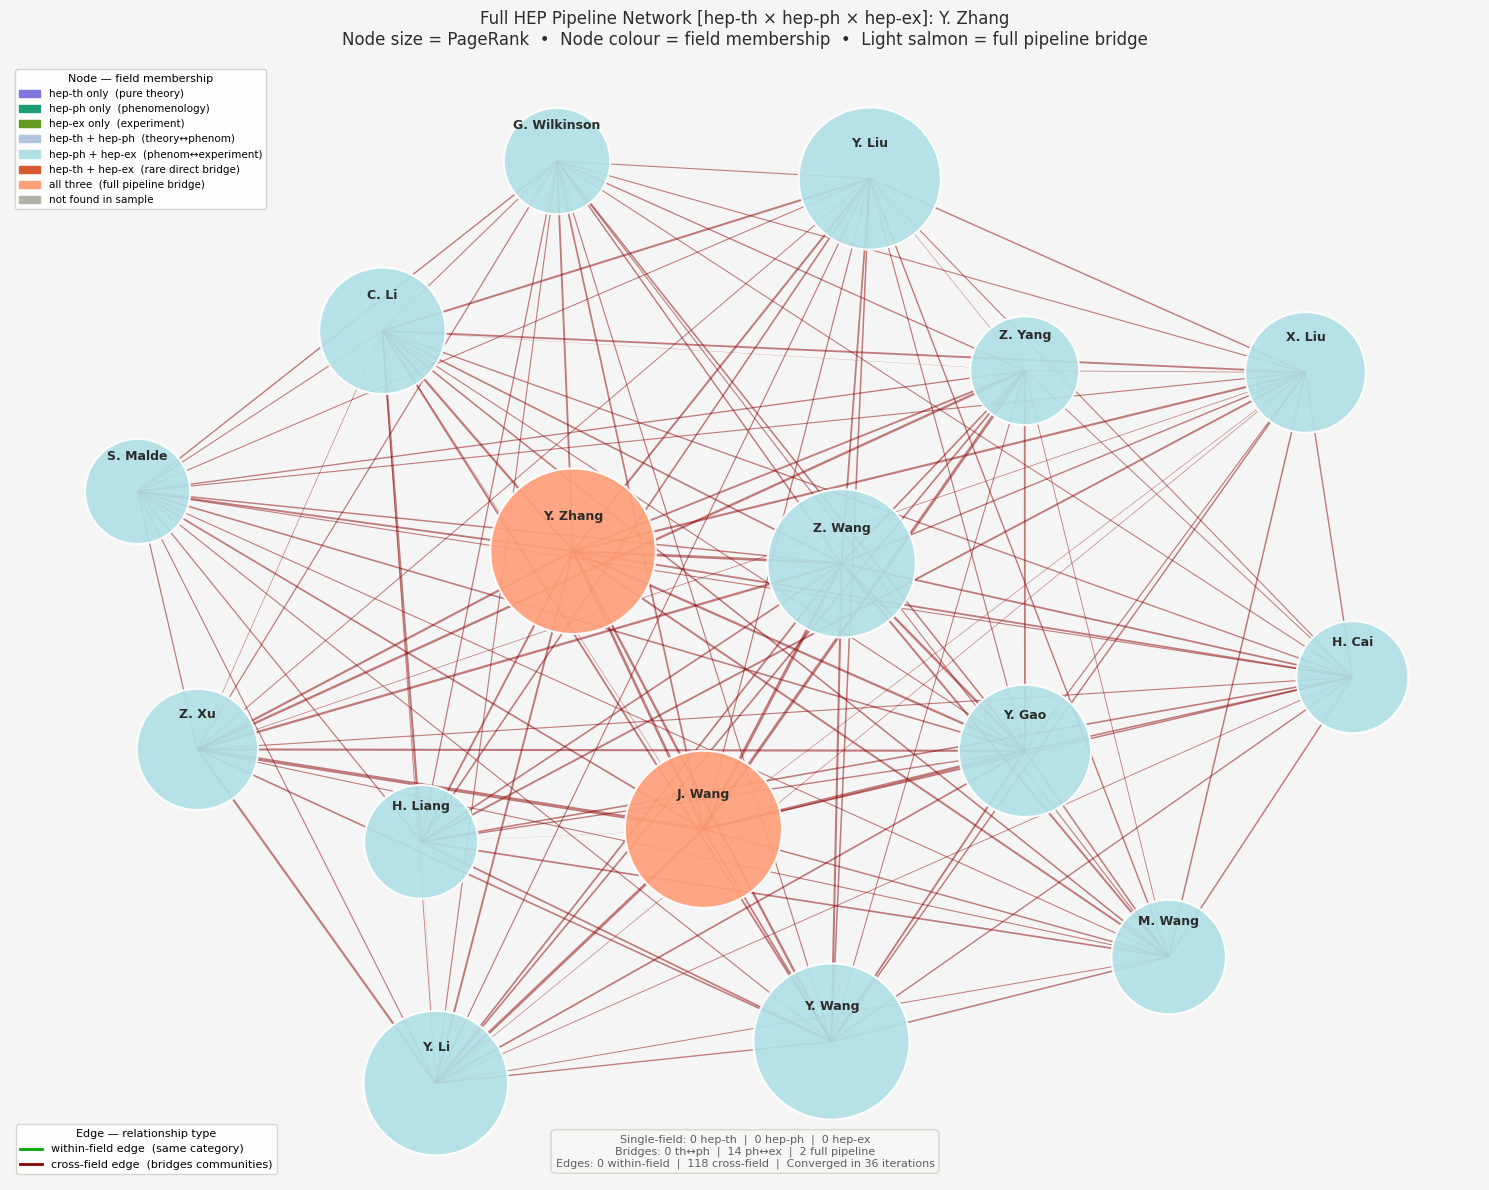

Graph saved as hep_three_category_graph.png


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — DRAW & SAVE NETWORK GRAPH
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(15, 12))
fig.patch.set_facecolor("#F5F5F5")
ax.set_facecolor("#F5F5F5")

nx.draw_networkx_edges(g, pos, edge_color=edge_colors_list,
                       width=edge_widths_list, alpha=0.5, ax=ax)
nx.draw_networkx_nodes(g, pos, node_color=node_colors_list,
                       node_size=node_sizes_list, alpha=0.92, ax=ax,
                       edgecolors='white', linewidths=1.5)

for node, (x, y) in pos.items():
    bridge_label = node_bridge_label(node)
    cats         = author_category_map.get(node, frozenset())
    is_notable   = (
        node == target_author
        or bridge_label is not None
        or len(cats) == 1
    )
    ax.text(x, y + 0.06, node,
            ha='center', va='bottom',
            fontsize=9 if is_notable else 7,
            fontweight='bold' if is_notable else 'normal',
            color='#2C2C2A')

# ── LEGENDS ───────────────────────────────────────────────────────────────────
node_legend = [
    mpatches.Patch(color=COLOR_TH,    label='hep-th only  (pure theory)'),
    mpatches.Patch(color=COLOR_PH,    label='hep-ph only  (phenomenology)'),
    mpatches.Patch(color=COLOR_EX,    label='hep-ex only  (experiment)'),
    mpatches.Patch(color=COLOR_TH_PH, label='hep-th + hep-ph  (theory\u2194phenom)'),
    mpatches.Patch(color=COLOR_PH_EX, label='hep-ph + hep-ex  (phenom\u2194experiment)'),
    mpatches.Patch(color=COLOR_TH_EX, label='hep-th + hep-ex  (rare direct bridge)'),
    mpatches.Patch(color=COLOR_ALL,   label='all three  (full pipeline bridge)'),
    mpatches.Patch(color=COLOR_UNK,   label='not found in sample'),
]
edge_legend = [
    Line2D([0], [0], color=EDGE_WITHIN, linewidth=2,
           label='within-field edge  (same category)'),
    Line2D([0], [0], color=EDGE_CROSS,  linewidth=2,
           label='cross-field edge  (bridges communities)'),
]

legend1 = ax.legend(handles=node_legend, title='Node \u2014 field membership',
                    loc='upper left', fontsize=7.5, title_fontsize=8,
                    framealpha=0.9, edgecolor='#D3D1C7')
ax.add_artist(legend1)
ax.legend(handles=edge_legend, title='Edge \u2014 relationship type',
          loc='lower left', fontsize=8, title_fontsize=8,
          framealpha=0.9, edgecolor='#D3D1C7')

# ── STATS ANNOTATION ──────────────────────────────────────────────────────────
n_th    = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-th'}))
n_ph    = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-ph'}))
n_ex    = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-ex'}))
n_th_ph = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-th', 'hep-ph'}))
n_ph_ex = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-ph', 'hep-ex'}))
n_all   = sum(1 for n in g.nodes() if author_category_map.get(n, frozenset()) == frozenset({'hep-th', 'hep-ph', 'hep-ex'}))
n_cross  = sum(1 for c in edge_colors_list if c == EDGE_CROSS)
n_within = sum(1 for c in edge_colors_list if c == EDGE_WITHIN)

stats_text = (
    f"Single-field: {n_th} hep-th  |  {n_ph} hep-ph  |  {n_ex} hep-ex\n"
    f"Bridges: {n_th_ph} th\u2194ph  |  {n_ph_ex} ph\u2194ex  |  {n_all} full pipeline\n"
    f"Edges: {n_within} within-field  |  {n_cross} cross-field  "
    f"|  Converged in {iteration} iterations"
)
ax.text(0.5, 0.01, stats_text, transform=ax.transAxes,
        ha='center', va='bottom', fontsize=8, color='#5F5E5A',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#F8F7F4',
                  edgecolor='#D3D1C7', alpha=0.9))

ax.set_title(
    f"Full HEP Pipeline Network [hep-th \u00d7 hep-ph \u00d7 hep-ex]: {target_author}\n"
    "Node size = PageRank  \u2022  Node colour = field membership  \u2022  "
    "Light salmon = full pipeline bridge",
    fontsize=12, color='#2C2C2A', pad=14
)
ax.axis('off')
plt.tight_layout()
plt.savefig("hep_three_category_graph.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph saved as hep_three_category_graph.png")
